# Getting Started with Body Pose

Body Pose enriches the 2D tracking data with **29 key points ("joints") per player**, each
positioned in 3D. This notebook works through loading it, the gating it needs, and one
worked feature — shoulder orientation.

**What you need to know before starting**

| | |
|---|---|
| Frame rate | **25 FPS**, against 10 FPS for tracking, events and phases |
| Coverage | Only detected players get pose — expect gaps |
| Accuracy | Every joint carries `p90_mae_cm`, its own predicted error |
| `z` | Accurate **relative to the player's centroid**, *not* in pitch coordinates |

That last point matters: `z` is not a height above the grass and can be negative. Treat it as
pose geometry, not elevation.

Full matches live on the [Hugging Face Hub](https://huggingface.co/datasets/SkillCorner/opendata-bodypose)
at roughly 600 MB each. This notebook uses the single phase of play committed to the repo, so
nothing needs downloading.

## 1. Load the sample

One 12.3 second Brisbane Roar quick break, second half of match 1925299.

In [1]:
import sys
sys.path.append("../../..")

import matplotlib.pyplot as plt
import pandas as pd

from src.data.pose_loading import (
    JOINTS, SKELETON, iter_sample, joints_to_frame, skeleton_segments,
)
from src.features.pose_orientation import gating_report, shoulder_table

# SkillCorner data-viz palette
GREEN, LIME, AZURE_PALE, AZURE, TEAL = "#00a82f", "#32fe6b", "#7acbff", "#2388c8", "#00838f"
STRUCT, GREY = "#252525", "#E8E8E8"

frames = list(iter_sample())
print(f"{len(frames)} pose frames, {frames[0]['frame']} to {frames[-1]['frame']}")
print(f"{len(JOINTS)} joints per player")

309 pose frames, 124487 to 124795
29 joints per player


## 2. What one record looks like

One JSON object per frame, with `player_data` carrying each player's 2D position and their
`joints` dictionary. A player whose pose could not be resolved has `joints = None` — their
`x`/`y` may still be there.

In [2]:
frame = frames[150]
print(f"frame {frame['frame']}  period {frame['period']}  t={frame['timestamp']}")
print(f"ball: {frame['ball_data']}")

with_pose = [p for p in frame["player_data"] if p["joints"]]
print(f"\nplayers in frame: {len(frame['player_data'])}  with pose: {len(with_pose)}")

player = with_pose[0]
print(f"\nplayer {player['player_id']} at ({player['x']}, {player['y']}):")
for name in ("lShoulder", "rShoulder", "lKnee", "lBigToe"):
    j = player["joints"][name]
    print(f"  {name:<11} xyz={j['xyz']}  p90_mae_cm={j['p90_mae_cm']}")

frame 124637  period 2  t=01:17:40.48
ball: {'x': 34.824, 'y': 29.992, 'z': 0.164, 'is_detected': True}

players in frame: 32  with pose: 17

player 809166 at (34.858, 7.898):
  lShoulder   xyz=[34.729, 7.808, 1.437]  p90_mae_cm=5.36
  rShoulder   xyz=[35.108, 7.878, 1.407]  p90_mae_cm=5.56
  lKnee       xyz=[34.746, 7.997, 0.473]  p90_mae_cm=10.33
  lBigToe     xyz=[34.678, 7.83, 0.012]  p90_mae_cm=26.49


## 3. Flatten to a table

`joints_to_frame` turns the nested records into one row per joint per player per frame, which
is the shape most analysis wants.

In [3]:
joints = joints_to_frame(iter_sample())
print(f"{len(joints):,} joint rows, {joints.player_id.nunique()} players")
joints.head()

143,637 joint rows, 21 players


,frame,period,player_id,joint,x,y,z,p90_mae_cm
0,124487,2,560989,lAnkle,24.264,-8.890,0.338,12.39
1,124487,2,560989,lEar,24.056,-8.397,1.828,6.00
2,124487,2,560989,lElbow,23.889,-8.672,1.334,8.16
3,124487,2,560989,lEye,24.005,-8.283,1.792,6.87
4,124487,2,560989,lHip,24.010,-8.553,0.995,7.27


## 4. Accuracy is not uniform — check before you trust

`p90_mae_cm` is defined so 90% of estimates sit within that radius of the true joint position,
relative to the player's pose. It varies a lot by landmark: torso and head are far more
reliable than fingers and toes.

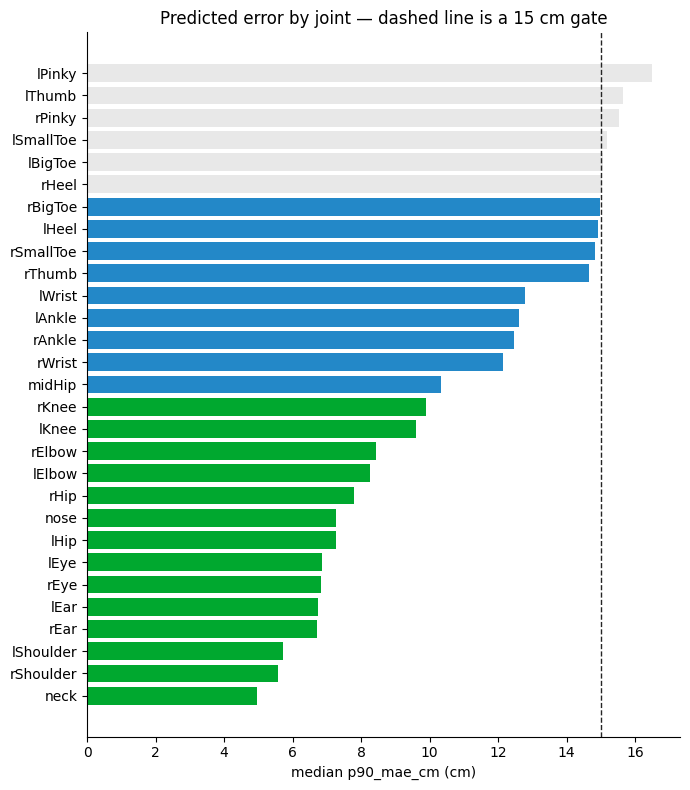

best:  neck at 5.0 cm
worst: lPinky at 16.5 cm


In [4]:
by_joint = joints.groupby("joint")["p90_mae_cm"].median().sort_values()

fig, ax = plt.subplots(figsize=(7, 8))
colors = [GREEN if v <= 10 else (AZURE if v <= 15 else GREY) for v in by_joint.values]
ax.barh(by_joint.index, by_joint.values, color=colors)
ax.axvline(15, color=STRUCT, ls="--", lw=1)
ax.set_xlabel("median p90_mae_cm (cm)")
ax.set_title("Predicted error by joint — dashed line is a 15 cm gate")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print(f"best:  {by_joint.index[0]} at {by_joint.iloc[0]:.1f} cm")
print(f"worst: {by_joint.index[-1]} at {by_joint.iloc[-1]:.1f} cm")

## 5. Draw a skeleton

`SKELETON` lists the joint pairs to connect as bones. Plotting the plan view `(x, y)` and the
front view `(x, z)` side by side shows why `z` is useful for posture even though it is not an
absolute height.

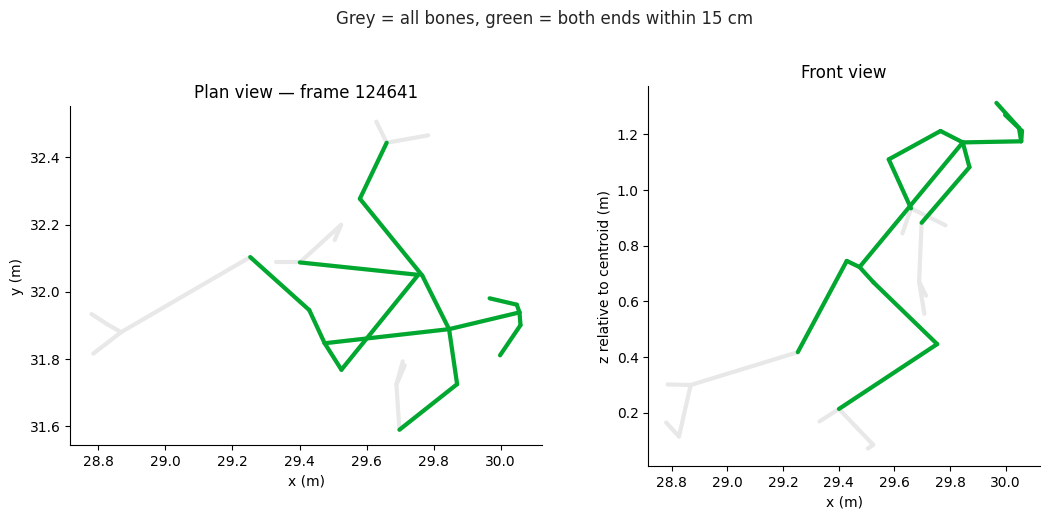

In [5]:
target = joints[joints.player_id == joints.player_id.mode()[0]]
frame_no = int(target.frame.iloc[len(target) // 2])
one = joints[(joints.player_id == target.player_id.iloc[0]) & (joints.frame == frame_no)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
for a, b in skeleton_segments(one):
    ax1.plot([a[0], b[0]], [a[1], b[1]], color=GREY, lw=3, solid_capstyle="round")
for a, b in skeleton_segments(one, max_mae_cm=15):
    ax1.plot([a[0], b[0]], [a[1], b[1]], color=GREEN, lw=3, solid_capstyle="round")
ax1.set(xlabel="x (m)", ylabel="y (m)", title=f"Plan view — frame {frame_no}")

for a, b in skeleton_segments(one):
    ax2.plot([a[0], b[0]], [a[2], b[2]], color=GREY, lw=3, solid_capstyle="round")
for a, b in skeleton_segments(one, max_mae_cm=15):
    ax2.plot([a[0], b[0]], [a[2], b[2]], color=GREEN, lw=3, solid_capstyle="round")
ax2.set(xlabel="x (m)", ylabel="z relative to centroid (m)", title="Front view")

for ax in (ax1, ax2):
    ax.set_aspect("equal")
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle("Grey = all bones, green = both ends within 15 cm", y=1.02, color=STRUCT)
fig.tight_layout()
plt.show()

## 6. A worked feature: shoulder orientation

`src/features/pose_orientation.py` computes the ground-plane direction the shoulders face —
the left→right shoulder axis rotated by +90°. 0° points along +x, counter-clockwise positive.

This is a baseline to show how to work with body pose and deduce vectors.

In [6]:
print(gating_report(iter_sample()).to_string(index=False))

                    gate  dropped  remaining
      player-frames seen        0       9888
    no pose (undetected)     4935       4953
      a shoulder missing        0       4953
      shoulders coincide        0       4953
width outside 0.15-0.6 m        5       4948
           error > 15 cm       57       4891


Note the width gate. A collapsed pose still yields an angle — the maths succeeds — but a
0.01 m shoulder width is anatomically impossible and the heading it gives is noise. Checking
only for exactly coincident points would let those through.

In [7]:
shoulders = shoulder_table(iter_sample())
print(f"{len(shoulders):,} rows, {shoulders.is_reliable.sum():,} reliable "
      f"({shoulders.is_reliable.mean():.1%})")

good = shoulders[shoulders.is_reliable]
bad = shoulders[~shoulders.is_reliable]
print(f"reliable shoulder width:   {good.shoulder_width_m.min():.3f}–{good.shoulder_width_m.max():.3f} m")
print(f"rejected shoulder width:   {bad.shoulder_width_m.min():.3f}–{bad.shoulder_width_m.max():.3f} m")
shoulders.head()

4,953 rows, 4,891 reliable (98.7%)
reliable shoulder width:   0.272–0.432 m
rejected shoulder width:   0.014–0.528 m


,frame,frame_10fps,period,t_s,player_id,shoulder_deg,shoulder_width_m,shoulder_err_cm,is_reliable,l_shoulder_x,l_shoulder_y,r_shoulder_x,r_shoulder_y
0,124487,49795,2,4979.48,11897,-152.226656,0.360534,5.76,True,23.020,13.387,22.852,13.706
1,124488,49795,2,4979.52,11897,-150.806591,0.360834,5.66,True,23.041,13.385,22.865,13.700
2,124489,49796,2,4979.56,11897,-151.890584,0.365059,5.78,True,23.055,13.419,22.883,13.741
3,124490,49796,2,4979.60,11897,-150.039427,0.362432,5.67,True,23.073,13.448,22.892,13.762
4,124491,49796,2,4979.64,11897,-149.308819,0.360494,5.68,True,23.075,13.459,22.891,13.769


> **If you differentiate shoulder heading, smooth it first.** At 25 FPS a couple of degrees of
> frame-to-frame jitter becomes tens of degrees per second, so a raw turn rate is
> noise-dominated rather than informative. Also remember the −180/180 wrap: a player crossing
> that boundary will appear to spin most of a full circle in one frame unless you unfold it.

## 7. Joining back to tracking, events and phases

Pose is 25 FPS and everything else in this repo is 10 FPS, so frame numbers are **not**
interchangeable:

```
pose_frame = 2.5 × tracking_frame
```

Every 5th pose frame lands exactly on an even tracking frame. `shoulder_table` already
provides `frame_10fps`, folded with the same rounding the rest of the pipeline uses, so it
joins directly.

In [8]:
phases = pd.read_csv("../../../data/matches/1925299/1925299_phases_of_play.csv")
phase = phases[phases["index"] == 406].iloc[0]

print(f"phase 406: {phase.team_in_possession_shortname} "
      f"{phase.team_in_possession_phase_type}, {phase.duration}s")
print(f"  tracking frames {phase.frame_start}–{phase.frame_end}")
print(f"  pose frames     {phase.frame_start * 2.5:.0f}–{phase.frame_end * 2.5:.0f}")

exact = good[good.frame % 5 == 0]
print(f"\npose frames aligning exactly to tracking: "
      f"{exact.frame.nunique()} of {good.frame.nunique()}")
good[["frame", "frame_10fps", "player_id", "shoulder_deg"]].head()

phase 406: Brisbane FC quick_break, 12.3s
  tracking frames 49795–49918
  pose frames     124488–124795

pose frames aligning exactly to tracking: 62 of 309


,frame,frame_10fps,player_id,shoulder_deg
0,124487,49795,11897,-152.226656
1,124488,49795,11897,-150.806591
2,124489,49796,11897,-151.890584
3,124490,49796,11897,-150.039427
4,124491,49796,11897,-149.308819


## 8. Moving up to a full match

Everything above ran on one phase. Full matches live on the
[Hugging Face Hub](https://huggingface.co/datasets/SkillCorner/opendata-bodypose) — roughly
600 MB zipped each, about 3.3 GB of JSON.

`data/bodypose/MANIFEST.json` records where the files live plus each one's size and SHA256, so
`download_match` can check what it fetched against what was published. The `revision` below is
which version of the dataset to fetch; `main` means whatever is currently published.

In [9]:
from src.data.pose_loading import manifest

meta = manifest()
print(f"dataset  {meta['hf_dataset']}")
print(f"revision {meta['hf_revision']}")
for match_id, info in meta["matches"].items():
    size = meta["files"][info["file"]]["size_bytes"] / 1024**2
    print(f"  {match_id}  {info['fixture']:<30} {info['date']}  {size:>6.0f} MB")

dataset  SkillCorner/opendata-bodypose
revision main
  1925299  Brisbane Roar v Perth Glory    2024-12-21     595 MB
  1996435  Sydney FC v Adelaide United    2025-02-01     614 MB


`download_match` fetches an archive once, checking it against the manifest, and `iter_match`
then streams frames straight out of the zip — no 3.3 GB extraction, constant memory.

The cell below is switched off so this notebook stays quick to run. Set the flag to `True`
to work with the real thing.

In [10]:
from src.data.pose_loading import download_match, iter_match, verify_download

DOWNLOAD_FULL_MATCH = False   # set True to fetch ~600 MB

if DOWNLOAD_FULL_MATCH:
    archive = download_match(1925299, dest_dir=".")
    print(f"downloaded {archive} — checksum ok: {verify_download(archive)}")

    # stream, do not accumulate: a full match is ~45 million joint observations
    frames = pose_frames = 0
    for frame in iter_match(archive):
        frames += 1
        if any(p["joints"] for p in frame["player_data"]):
            pose_frames += 1
    print(f"{frames:,} frames, {pose_frames:,} with pose")
else:
    print("DOWNLOAD_FULL_MATCH is False — skipping the 600 MB download.")
    print("The sample used above covers tracking frames 49795–49918 of match 1925299.")

DOWNLOAD_FULL_MATCH is False — skipping the 600 MB download.
The sample used above covers tracking frames 49795–49918 of match 1925299.


Nothing here is required to use the data. The files are plain HTTP, so this works standalone:

```python
import io, json, zipfile, urllib.request

URL = ("https://huggingface.co/datasets/SkillCorner/opendata-bodypose"
       "/resolve/main/raw/1925299.jsonl.zip")

with urllib.request.urlopen(URL) as response:
    blob = io.BytesIO(response.read())

with zipfile.ZipFile(blob) as zf, zf.open("1925299.jsonl") as fh:
    for line in fh:
        frame = json.loads(line)
```

Or via `huggingface_hub` if you want caching and resume:

```python
from huggingface_hub import hf_hub_download

path = hf_hub_download(
    repo_id="SkillCorner/opendata-bodypose",
    filename="raw/1925299.jsonl.zip",
    repo_type="dataset",
)
```

## For inspiration

[US Soccer Federation — Visual Exploratory Behavior (SSAC 2026)](https://github.com/USSoccerFederation/ssac26_visual_exploratory_behavior)
